# ML Homework 5 Guide


1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW5.ipynb" to "HW5\_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

\*\* 6. Upload the saved 'Original vs Reconstructed Data' image files for both the worst and best models.

\*\* 7. Upload the saved 'Latent Space Visualization (t-SNE)' image file for both the worst and best models.


# [HW 5] Grid Search for ConvAE and Visualization

1. Load your 'SoundSTFT.npy' file as you loaded in the 'ML10_Code1'.
2. Prepare training and test dataset with the test data ratio of """10%""".
3. Perform a grid search to find the best dimension of bottle neck layer for the ConvAE model.

- You don't need to search other hyperparameters.

4. Determine your best and worst CNN model based on reconstruction error.
5. Compare original and reconstructed STFT spectrogram for both the worst and best models and save them as image files (.png or .jpg).

- Upload the comparison images to BrightSpace with ipynb and pdf files

6. Extract latent space features from both the worst and best models and visualize them using t-SNE.

- Save and upload the visualization results to BrightSpace as well.


### Install & Imports


In [3]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp
from scipy import signal

import librosa
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("librosa   :", librosa.__version__)

TensorFlow: 2.19.0
librosa   : 0.11.0


### Data Loading, Indexing & Segmentation


In [4]:
# Download the industrial sound recording
file_url = (
    "https://github.com/purduelamm/purdue_me597_iiot/blob/main/"
    "ml_tutorial/Dataset_IndustrialSound/Industrial_data_Stethoscope.wav?raw=true"
)
file_path = "Industrial_data_Stethoscope.wav"
urllib.request.urlretrieve(file_url, file_path)

sound, rate = librosa.load(file_path, sr=None)

CLASS_NAMES = [
    "Tool Change",
    "Chip Conveyer",
    "Moving X",
    "Moving Y",
    "Moving Z",
    "Spindle",
]
NUM_CLASS = len(CLASS_NAMES)

timestamps = [12.46, 32.51, 65.57, 95.30, 104.36, 112.12]
indices = np.multiply(rate, timestamps).astype(np.int64)

# Split into class segments
raw_classes = []
for i in range(NUM_CLASS):
    if i == NUM_CLASS - 1:
        raw_classes.append(sound[indices[i] :])
    else:
        raw_classes.append(sound[indices[i] : indices[i + 1]])

# Fixed-length segmentation: 1-second window, 0.8-second overlap
SEGMENT_LEN = int(1.0 * rate)
OVERLAP = int(0.8 * rate)
STEP = SEGMENT_LEN - OVERLAP


def segmentation(data):
    segs, start = [], 0
    while start + SEGMENT_LEN <= len(data):
        segs.append(data[start : start + SEGMENT_LEN])
        start += STEP
    return np.array(segs, dtype=np.float32)


segments_per_class = [segmentation(c) for c in raw_classes]

### Prepare Training and Test Dataset


In [ ]:
TEST_RATIO = 0.10  # Test data ratio as per instruction 2
VAL_RATIO = 0.15  # fraction of training data held out for validation
RANDOM_STATE = 42

train_segs, test_segs = [], []
train_labels_list, test_labels_list = [], []

for class_idx, segs in enumerate(segments_per_class):
    tr, te = train_test_split(
        segs, test_size=TEST_RATIO, random_state=RANDOM_STATE
    )
    train_segs.append(tr)
    test_segs.append(te)
    train_labels_list.extend([class_idx] * len(tr))
    test_labels_list.extend([class_idx] * len(te))

X_train_raw = np.concatenate(train_segs, axis=0)
X_test_raw = np.concatenate(test_segs, axis=0)
y_train = np.array(train_labels_list)
y_test = np.array(test_labels_list)

# ── Stratified validation split ───────────────────────────────────────────
# keras validation_split takes the LAST N% of the array before shuffling.
# Because classes are concatenated in order, that slice is dominated by the
# last class, causing biased validation metrics (val_acc starts at 1.0 then
# collapses for the CNN).  A stratified split guarantees every class appears
# at the correct proportion in both halves — regardless of model or epoch.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=VAL_RATIO,
    stratify=y_train,  # <── key: preserves class proportions
    random_state=RANDOM_STATE,
)

print(
    f"Train : {X_train_raw.shape[0]} segments  class dist: {np.bincount(y_train)}"
)
print(
    f"Val   : {X_val_raw.shape[0]}  segments  class dist: {np.bincount(y_val)}"
)
print(
    f"Test  : {X_test_raw.shape[0]}  segments  class dist: {np.bincount(y_test)}"
)

Train : 473 segments  class dist: [ 73 122 110  31  25 112]
Val   : 84  segments  class dist: [13 22 19  5  5 20]
Test  : 66  segments  class dist: [10 17 15  5  4 15]


In [21]:
def preprocess_to_mels(raw_data, sr=48000, n_mels=32, n_cols=32):
    # Calculate hop_length to get exactly 32 columns
    # We use (n_cols - 1) because librosa adds a frame for the start
    hop_length = int(raw_data.shape[1] / (n_cols - 1))

    processed_list = []

    for signal in raw_data:
        # 1. Generate Mel Spectrogram
        mels = librosa.feature.melspectrogram(
            y=signal, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=2048
        )

        # 2. Trim/Pad to ensure exactly 32 columns (librosa can vary by 1)
        mels = mels[:, :n_cols]

        # 3. Convert to Log Scale (decibels) - better for Neural Networks
        mels_db = librosa.power_to_db(mels, ref=np.max)

        # 4. Normalize between 0 and 1 (Required for Sigmoid in ConvAE)
        mels_norm = (mels_db - mels_db.min()) / (
            mels_db.max() - mels_db.min() + 1e-6
        )

        processed_list.append(mels_norm)

    # Convert list to array and add the channel dimension (None, 32, 32, 1)
    X_processed = np.array(processed_list)[..., np.newaxis]
    return X_processed

### ConvAE


In [36]:
def build_convae(bottleneck, input_shape=(32, 32, 1)):
    encoder_input = layers.Input(shape=input_shape)

    # Encoder Block 1: (32, 32, 1) -> (16, 16, 16)
    x = layers.Conv2D(16, (3, 3), padding="same")(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)

    # Encoder Block 2 (Bottleneck): (16, 16, 16) -> (16/h, 16/w, 32)
    x = layers.Conv2D(32, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    encoded = layers.MaxPooling2D(pool_size=bottleneck, padding="same")(x)

    # Decoder Block 1
    x = layers.UpSampling2D(size=bottleneck)(encoded)
    x = layers.Conv2D(16, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Reverse Block 1: (16,16) -> (32,32)
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(1, (3, 3), padding="same")(x)
    decoded = layers.Activation("sigmoid")(x)

    autoencoder = Model(encoder_input, decoded)
    autoencoder.compile(optimizer="adam", loss="mse")
    return autoencoder

In [34]:
def grid_search(x_train, x_val, bottleneck_candidates, epochs=10):
    results = {}

    for size in bottleneck_candidates:
        print(f"Testing bottleneck size: {size}")
        model = build_convae(bottleneck=size)

        # Train the model
        history = model.fit(
            x_train,
            x_train,
            epochs=epochs,
            batch_size=32,
            validation_data=(x_val, x_val),
            verbose=0,  # Keep console clean
        )

        final_loss = history.history["val_loss"][-1]
        results[size] = final_loss
        print(f"Resulting Val MSE: {final_loss:.6f}")

    best_size = min(results, key=results.get)
    worst_size = max(results, key=results.get)

    print("\n--- Grid Search Results ---")
    print(f"Best Bottleneck Size: {best_size} (MSE: {results[best_size]:.6f})")
    print(
        f"Worst Bottleneck Size: {worst_size} (MSE: {results[worst_size]:.6f})"
    )

    return results, best_size, worst_size

In [37]:
candidates = [(2, 2), (4, 4), (2, 4), (8, 8)]
X_train_prep = preprocess_to_mels(X_train_raw)
X_val_prep = preprocess_to_mels(X_val_raw)

results, best, worst = grid_search(X_train_prep, X_val_prep, candidates)

Testing bottleneck size: (2, 2)
Resulting Val MSE: 0.055059
Testing bottleneck size: (4, 4)
Resulting Val MSE: 0.070320
Testing bottleneck size: (2, 4)
Resulting Val MSE: 0.052239
Testing bottleneck size: (8, 8)
Resulting Val MSE: 0.061312

--- Grid Search Results ---
Best Bottleneck Size: (2, 4) (MSE: 0.052239)
Worst Bottleneck Size: (4, 4) (MSE: 0.070320)


### Visualize Reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step


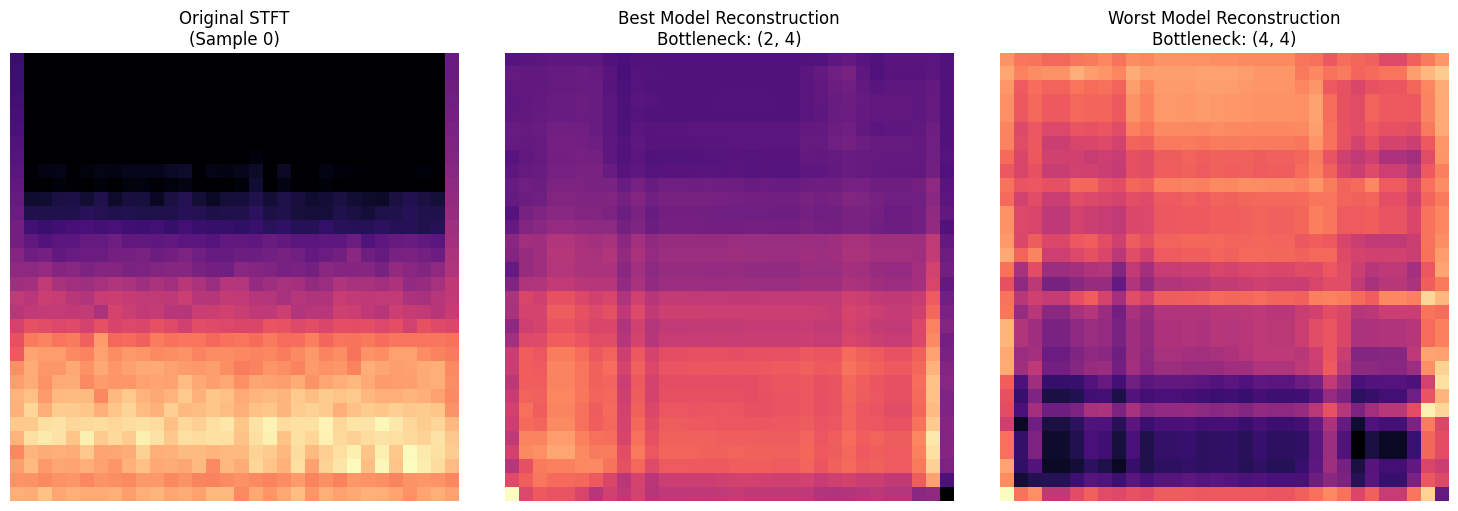

In [38]:
def compare_reconstructions(x_val, best_size, worst_size, sample_idx=0):
    model_best = build_convae(bottleneck=best_size)
    reconstructed_best = model_best.predict(x_val[sample_idx : sample_idx + 1])
    model_worst = build_convae(bottleneck=worst_size)
    reconstructed_worst = model_worst.predict(
        x_val[sample_idx : sample_idx + 1]
    )

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original
    axes[0].imshow(x_val[sample_idx].squeeze(), cmap="magma", origin="lower")
    axes[0].set_title(f"Original STFT\n(Sample {sample_idx})")

    # Best
    axes[1].imshow(
        reconstructed_best[0].squeeze(), cmap="magma", origin="lower"
    )
    axes[1].set_title(f"Best Model Reconstruction\nBottleneck: {best_size}")

    # Worst
    axes[2].imshow(
        reconstructed_worst[0].squeeze(), cmap="magma", origin="lower"
    )
    axes[2].set_title(f"Worst Model Reconstruction\nBottleneck: {worst_size}")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()


compare_reconstructions(X_val_prep, best, worst)

### t-SNE Plots

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
Running t-SNE for Best model...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
Running t-SNE for Worst model...


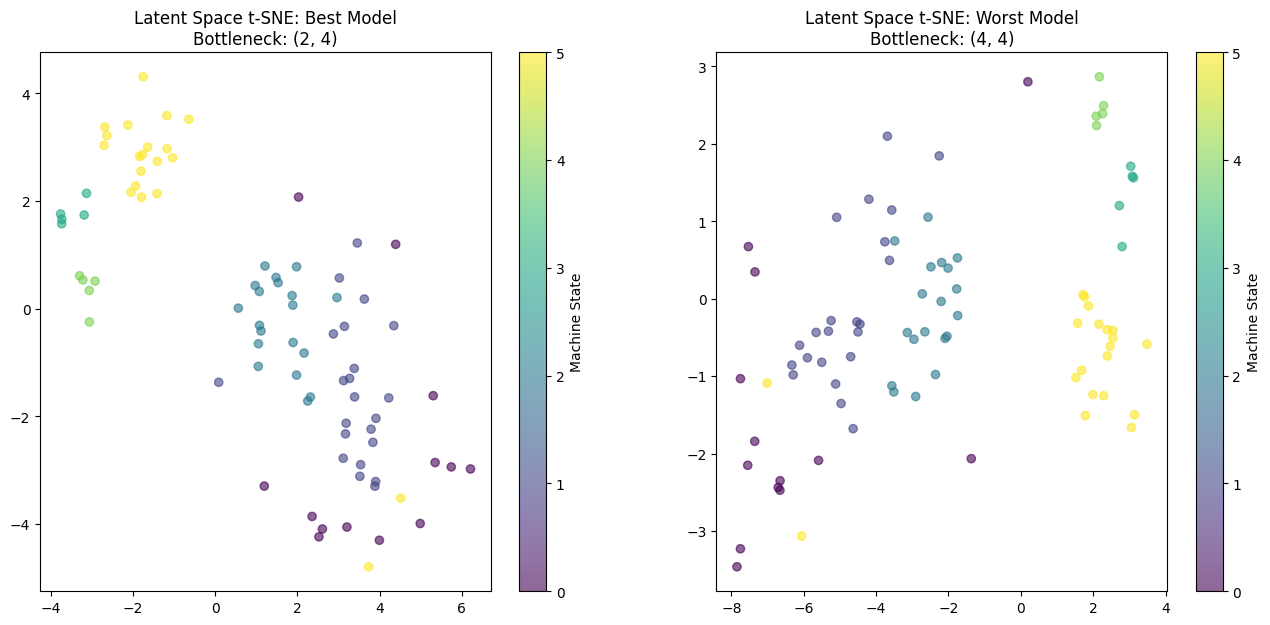

In [39]:
from sklearn.manifold import TSNE


def visualize_tsne(x_val, y_labels, best_size, worst_size):
    models_to_check = [("Best", best_size), ("Worst", worst_size)]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for i, (name, size) in enumerate(models_to_check):
        full_model = build_convae(bottleneck=size)
        encoder_only = Model(
            inputs=full_model.input,
            outputs=full_model.get_layer(index=7).output,
        )

        latent_features = encoder_only.predict(x_val)
        latent_flat = latent_features.reshape(latent_features.shape[0], -1)

        print(f"Running t-SNE for {name} model...")
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        tsne_results = tsne.fit_transform(latent_flat)

        scatter = axes[i].scatter(
            tsne_results[:, 0],
            tsne_results[:, 1],
            c=y_labels,
            cmap="viridis",
            alpha=0.6,
        )
        axes[i].set_title(
            f"Latent Space t-SNE: {name} Model\nBottleneck: {size}"
        )
        fig.colorbar(scatter, ax=axes[i], label="Machine State")
    plt.show()


y_labels_int = np.argmax(y_val_oh, axis=1)

visualize_tsne(X_val_prep, y_labels_int, best, worst)

## ML7 and ML8 Summary and Deliverables

Answer the following questions for your achievements


### Q1. Please summarize ML7 and ML8.

---

In ML7, we continued learning more about artificial and convolutional neural networks and learned how to perform a grid search using different hyperparameters to find the best model. We continued to learn how to prepare a data processing pipeline using a FeatureData dataset for the ANN, and an acceleration dataset for the CNN. Finally, we learned how to verify which model was best after the outcome of the grid search.

In ML8, we analyzed acceleration data once again but this time applied it to fault detection. First, we preprocessed the vibration data to a different frequency and normalized it to a -1.0 to 1.0 scale, since the YAMNet model we are using expects this normalization. We then assigned labels like we do with other ML models. Finally, we trained a model and evaluated it similarly to previous ML examples.

---


### Q2. What skills did you have to develop to accomplish this project?

---

For this project, I developed my knowledge of machine learning architectures, specifically for the ConvAE model.

---


### Q3. What aspects of this project were the most beneficial for your learning?

---

The aspects of this project that were the most beneficial for my learning were the use of a real world dataset and doing the grid search to figure out what modifying a single hyperparameter would do.

---


### Q4. What challenges did you encounter in completing the project?

---

The challenges that I encountered in completing this project were doing my own research into what a ConvAE model is, and how to use and train one.

---


### Q5. How did you overcome the challenges or remedy the problems encountered?

---

I overcame this challenge by reviewing other autoencoder models and CNN models to better understand the architecture. I consulted Google Gemini to assist with building a ConvAE model using Keras and it specifically advised me how to use an UpSampling2D layer and helped me make t-SNE plots.

---
